In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
import sys

print(sys.executable)
print(sys.version)

c:\Users\noahp\anaconda3\python.exe
3.14.6 | packaged by Anaconda, Inc. | (main, Jul  9 2026, 14:29:05) [MSC v.1942 64 bit (AMD64)]


Importing file into VS Code

In [3]:
df = pd.read_csv('messy_small_business_financial_operations.csv')
df.head()

,transaction_id,transaction_date,record_type,customer,product_service,product_sku,category,quantity,unit_price,gross_sales,...,inventory_units_delta,inventory_value_delta,ar_delta,ap_delta,payment_method,payment_status,vendor,invoice_due_date,notes,source_file
0,TXN-000762,29-Sep-25,SALE,Union Square Hotel,Soap Dispenser,DSP-100,Washroom Supplies,1.0,33.6,$33.60,...,-1,-16.8,0,$0.00,Check,Paid,NaN,9/29/2025,repeat customer,sales_export_2025_09.csv
1,TXN-000516,2/25/2024,Sale,Yellow Finch Design,Toilet Tissue Case,PPR-200,Paper Products,2.0,$41.80,83.6,...,-2,USD -51.60,0,0,Check,Paid,NaN,2/25/2024,Rush delivery,sales_export_2024_02.csv
2,TXN-000579,8/29/2025,Sale,Evergreen Fitness,Trash Bags 55 Gal,BAG-100,Waste Supplies,3.0,30.45,91.35,...,-3,-46.2,0,0,ACH,Paid,NaN,8/29/2025,Rush delivery,sales_export_2025_08.csv
3,TXN-000625,7/8/2024,SALE,dover legal partners,Mop Handle,MOP-200,Janitorial Equipment,6.0,24,144,...,-6,-69,0,$0.00,Cash,Paid,NaN,7/8/2024,monthly replenishment,sales_export_2024_07.csv
4,TXN-000060,11/18/2025,SALE,UNION SQUARE HOTEL,All-Purpose Cleaner,CLN-100,Cleaning Supplies,5.0,8.93,44.65,...,-5,-15.5,0,0,Cash,Paid,NaN,18-Nov-25,web order,sales_export_2025_11.csv


In [4]:
df.isnull().sum()

transaction_id              0
transaction_date            0
record_type                 0
customer                  381
product_service           198
product_sku               290
category                    0
quantity                  289
unit_price                290
gross_sales               470
discount_rate             470
discount_amount           470
net_sales                 471
cogs_amount               470
operating_expense        2018
inventory_units_delta       0
inventory_value_delta       0
ar_delta                    0
ap_delta                    0
payment_method              0
payment_status              0
vendor                   1771
invoice_due_date          289
notes                     440
source_file                 0
dtype: int64

In [5]:
df.record_type

0                    SALE
1                    Sale
2                    Sale
3                    SALE
4                    SALE
              ...        
2145    Operating Expense
2146                 SALE
2147     Customer Payment
2148                sales
2149              EXPENSE
Name: record_type, Length: 2150, dtype: str

In [6]:
#counts the values of each row in record type
df['record_type'].value_counts()

record_type
sales                 564
SALE                  563
Sale                  553
inventory purchase     68
PURCHASE               57
Inventory Purchase     56
EXPENSE                48
expense                46
AR Receipt             41
Operating Expense      38
ar receipt             26
Vendor Payment         25
Customer Payment       24
AP Payment             23
ap payment             18
Name: count, dtype: int64

In [7]:
#clean records type column by stripping spaces and standardizing casing
df['record_type_clean']=(df['record_type'].str.strip().str.casefold())

#changes sales to just sale
df['record_type_clean'] = df['record_type_clean'].replace({'sales':'sale'})

#checking value counts
df['record_type_clean'].value_counts()

record_type_clean
sale                  1680
inventory purchase     124
expense                 94
ar receipt              67
purchase                57
ap payment              41
operating expense       38
vendor payment          25
customer payment        24
Name: count, dtype: int64

In [8]:
#looking at these columns and the duplicates
df[['record_type','record_type_clean']].drop_duplicates()

,record_type,record_type_clean
0,SALE,sale
1,Sale,sale
5,expense,expense
6,PURCHASE,purchase
8,sales,sale
17,inventory purchase,inventory purchase
19,AR Receipt,ar receipt
20,ar receipt,ar receipt
24,EXPENSE,expense
30,Inventory Purchase,inventory purchase


In [9]:
#uncovering unclear data
df.loc[df['record_type_clean'].isin(['purchase', 'expense']),['record_type_clean','category','notes']]

,record_type_clean,category,notes
5,expense,Software,recurring monthly charge
6,purchase,Washroom Supplies,stock replenishment
24,expense,Payroll,recurring monthly charge
28,expense,Office Supplies,approved by owner
32,expense,Utilities,NaN
...,...,...,...
2075,purchase,Paper Products,stock replenishment
2097,purchase,Janitorial Equipment,stock replenishment
2127,purchase,Washroom Supplies,stock replenishment
2131,expense,Utilities,NaN


In [10]:
#looking at the rows based on the column to get every match for purchase 
purchase_rows = df.loc[df['record_type_clean']=='purchase']

#shows each purchase under each category
purchase_rows['category'].value_counts()

category
Janitorial Equipment    18
Washroom Supplies       12
Paper Products          12
Cleaning Supplies        8
Safety Supplies          4
Waste Supplies           3
Name: count, dtype: int64

In [11]:
#looks at the other columns associated with purchases
purchase_rows[
    ["category", "product_service", "product_sku",
     "inventory_units_delta", "inventory_value_delta",
     "operating_expense", "notes"]
].head(10)

,category,product_service,product_sku,inventory_units_delta,inventory_value_delta,operating_expense,notes
6,Washroom Supplies,Hand Sanitizer 1 Gal,SAN-100,24,244.22,NaN,stock replenishment
69,Janitorial Equipment,Mop Handle,MOP-200,36,$397.44,NaN,NaN
95,Washroom Supplies,Soap Dispenser,DSP-100,24,387.07,NaN,vendor shipment received
195,Paper Products,Paper Towel Case,PPR-100,24,$495.36,NaN,stock replenishment
206,Cleaning Supplies,Glass Cleaner,CLN-200,72,176.26,NaN,stock replenishment
210,Janitorial Equipment,Mop Handle,MOP-200,24,$281.52,NaN,stock replenishment
312,Washroom Supplies,Soap Dispenser,DSP-100,60,"$1,008.00",NaN,vendor shipment received
430,Janitorial Equipment,Microfiber Mop Head,MOP-100,48,$435.74,NaN,NaN
472,Cleaning Supplies,All-Purpose Cleaner,CLN-100,36,107.14,NaN,NaN
510,Janitorial Equipment,Mop Handle,MOP-200,120,"1,324.80",NaN,NaN


In [12]:
#checking the expense rows before classifiying purchases
expense_rows=df.loc[df['record_type_clean']=='expense']

expense_rows['category'].value_counts()

category
Payroll            17
Insurance          15
Delivery Fuel      13
Software           12
Office Supplies    11
Utilities           9
Rent                9
Marketing           8
Name: count, dtype: int64

In [13]:
#checking if expenses have cost in cogs and op ex 
expense_rows[["category", "operating_expense", "cogs_amount"]].head(10)

,category,operating_expense,cogs_amount
5,Software,142.71,NaN
24,Payroll,"1,215.48",NaN
28,Office Supplies,$89.68,NaN
32,Utilities,319.79,NaN
35,Marketing,$569.11,NaN
47,Office Supplies,USD 117.18,NaN
76,Software,155.1,NaN
92,Payroll,1437.74,NaN
97,Rent,3255.72,NaN
103,Payroll,"1,393.64",NaN


In [14]:
#checking if each expense has an operating expense cost
expense_rows['operating_expense'].isna().sum()

np.int64(0)

In [15]:
#changing all expense to operating expense
df['record_type_clean'] = df['record_type_clean'].replace({'expense':'operating expense'})

df['record_type_clean'].value_counts()

record_type_clean
sale                  1680
operating expense      132
inventory purchase     124
ar receipt              67
purchase                57
ap payment              41
vendor payment          25
customer payment        24
Name: count, dtype: int64

In [16]:
#Ensuring that these purchases are not operating expenses
purchase_rows[['inventory_units_delta','inventory_value_delta', 'operating_expense']].isna().sum()

inventory_units_delta     0
inventory_value_delta     0
operating_expense        57
dtype: int64

In [17]:
#looking to see if there is movement on these purchases
purchase_rows['inventory_units_delta'].value_counts()

inventory_units_delta
24     14
60     12
72      7
120     7
36      6
48      6
96      5
Name: count, dtype: int64

In [18]:
#changing purchase to inventory purchase
df['record_type_clean'] = df['record_type_clean'].replace({'purchase':'inventory purchase'})

df['record_type_clean'].value_counts() 

record_type_clean
sale                  1680
inventory purchase     181
operating expense      132
ar receipt              67
ap payment              41
vendor payment          25
customer payment        24
Name: count, dtype: int64

In [19]:
#verifying the amount of duplicate values in the df
df.duplicated().sum()

np.int64(35)

In [20]:
#Created a dataframe that has no exact duplicate values
df_clean = df.drop_duplicates()

len(df_clean)

2115

In [21]:
#Ensuring that the transactions ids are not the same
df_clean['transaction_id'].duplicated().sum()

np.int64(0)

In [22]:
df['transaction_date'].head(20)

0      29-Sep-25
1      2/25/2024
2      8/29/2025
3       7/8/2024
4     11/18/2025
5       5/7/2025
6       8/1/2024
7      9/26/2025
8      10/4/2024
9      26-Jul-25
10     4/28/2025
11      5/2/2024
12     31-Mar-24
13     6/15/2025
14     3/15/2024
15      1/5/2024
16     7/29/2024
17      5/9/2024
18     5/19/2024
19    12/31/2025
Name: transaction_date, dtype: str

In [23]:
#Convert mixed-format date text to dates; mark values that cannot be parsed as NaT
df_clean['date_clean'] = pd.to_datetime(df_clean['transaction_date'],format='mixed',errors='coerce')

#checking how many dates couldn't be converted
df_clean['date_clean'].isna().sum()

np.int64(2)

In [24]:
#checking the NAT dates and record type
df_clean.loc[df_clean['date_clean'].isna(), ['transaction_id', 'transaction_date','record_type_clean']]

,transaction_id,transaction_date,record_type_clean
1349,TXN-000397,2024-13-40,sale
1930,TXN-000907,2024-13-40,sale


In [25]:
# Create a DataFrame containing only transactions with valid dates
dated_transaction = df_clean.dropna(subset=['date_clean'])

len(dated_transaction)

2113

In [26]:
#checking the format of sales, dropna is to not see null values for now
dated_transaction['net_sales'].dropna().head(10)

0       $33.60 
1         79.42
2         82.21
3      $136.80 
4         44.65
7     USD 13.77
8        $6.55 
9       $41.34 
10     $290.00 
11     $130.50 
Name: net_sales, dtype: str

In [27]:
#creating a new column that removes the $ from sales
dated_transaction['net_sales_text']=dated_transaction['net_sales'].str.strip().str.replace('$','',regex=False)

dated_transaction['net_sales_text'].head(10)

0        33.60
1        79.42
2        82.21
3       136.80
4        44.65
5          NaN
6          NaN
7    USD 13.77
8         6.55
9        41.34
Name: net_sales_text, dtype: str

In [28]:
#removed USD from net sales
dated_transaction['net_sales_text'] = dated_transaction['net_sales_text'].str.replace('USD','')

dated_transaction['net_sales_text'].dropna().head(10)

0      33.60
1      79.42
2      82.21
3     136.80
4      44.65
7      13.77
8       6.55
9      41.34
10    290.00
11    130.50
Name: net_sales_text, dtype: str

In [29]:
#Checking the spacing of vales
text = dated_transaction["net_sales_text"].dropna()
(text != text.str.strip()).sum()

np.int64(144)

In [30]:
#turing sales text values to numerical values
dated_transaction['net_sales_number'] = pd.to_numeric(
    dated_transaction['net_sales_text'].str.replace(',','',regex=False).str.strip(),errors='coerce')

In [31]:
#creating data frame for sales to check missing values
sales_row = dated_transaction.loc[dated_transaction['record_type_clean']=='sale']

sales_row.isna().sum()

transaction_id              0
transaction_date            0
record_type                 0
customer                    2
product_service             0
product_sku                 1
category                    0
quantity                    0
unit_price                  1
gross_sales                 0
discount_rate               0
discount_amount             0
net_sales                   1
cogs_amount                 0
operating_expense        1648
inventory_units_delta       0
inventory_value_delta       0
ar_delta                    0
ap_delta                    0
payment_method              0
payment_status              0
vendor                   1648
invoice_due_date            0
notes                     331
source_file                 0
record_type_clean           0
date_clean                  0
net_sales_text              1
net_sales_number            1
dtype: int64

In [32]:
#checking for the na
sales_row.loc[sales_row['net_sales_number'].isna(),["transaction_id", "gross_sales", "discount_amount",
     "net_sales", "net_sales_number", "customer", "product_sku"]]


,transaction_id,gross_sales,discount_amount,net_sales,net_sales_number,customer,product_sku
1531,TXN-001555,$38.00,$5.70,NaN,NaN,Tidal Wave Media,PPR-100


In [33]:
#creating data frame for sales to check missing values
sales_row = dated_transaction.loc[
    dated_transaction["record_type_clean"] == "sale"
]



In [34]:
#created new columns to clean gross sales column, turning into text and then numbers
dated_transaction['gross_text'] =  dated_transaction['gross_sales'].str.replace('$','',regex=False).str.replace('USD','',regex=False).str.replace(',','',regex=False).str.strip()

dated_transaction['gross_sales_number'] = pd.to_numeric( dated_transaction['gross_text'],errors='coerce')
dated_transaction['gross_sales_number'].head(10)

0     33.60
1     83.60
2     91.35
3    144.00
4     44.65
5       NaN
6       NaN
7     14.50
8      6.89
9     41.34
Name: gross_sales_number, dtype: float64

In [35]:
#reruning this code to include gross sales
sales_row = dated_transaction.loc[dated_transaction['record_type_clean']=='sale']


#checking gross sales NAs
sales_row["gross_sales_number"].isna().sum()

np.int64(0)

In [36]:
#cleaning discount amount and changing to a number
dated_transaction['discount_text'] = dated_transaction['discount_amount'].str.replace('$','',regex=False).str.replace('USD','',regex=False).str.replace(',','',regex=False).str.strip()

dated_transaction['discount_amount_number'] = pd.to_numeric(dated_transaction['discount_text'],errors='coerce')

In [37]:
#reruning this code to include discount amouunt
sales_row = dated_transaction.loc[dated_transaction['record_type_clean']=='sale']

sales_row['discount_amount_number'].isna().sum()

np.int64(0)

In [38]:
#checking for the na
sales_row.loc[sales_row['net_sales_number'].isna(),["transaction_id", "gross_sales_number", "discount_amount_number",
     "net_sales", "net_sales_number", "customer", "product_sku"]]

,transaction_id,gross_sales_number,discount_amount_number,net_sales,net_sales_number,customer,product_sku
1531,TXN-001555,38.0,5.7,NaN,NaN,Tidal Wave Media,PPR-100


In [39]:
#creating net sales column
dated_transaction['net_sales_calculated'] = dated_transaction['gross_sales_number'] - dated_transaction['discount_amount_number']

#reruning this code to include net sales calculated
sales_row = dated_transaction.loc[dated_transaction['record_type_clean']=='sale']

sales_row.loc[sales_row['net_sales_number'].isna(),["transaction_id", "gross_sales_number", "discount_amount_number",
     "net_sales", "net_sales_number", "customer", "product_sku","net_sales_calculated"]]

,transaction_id,gross_sales_number,discount_amount_number,net_sales,net_sales_number,customer,product_sku,net_sales_calculated
1531,TXN-001555,38.0,5.7,NaN,NaN,Tidal Wave Media,PPR-100,32.3


In [40]:
#creating a check to ensure that the data 00000225
dated_transaction['net_sales_check'] = round(dated_transaction['net_sales_number'] - dated_transaction['net_sales_calculated'],2)

sales_row = dated_transaction.loc[dated_transaction['record_type_clean']=='sale']

#checking any abnormaties with net_sales_check 
sales_row.loc[sales_row['net_sales_number'].notna(), ['net_sales_number', 'net_sales_calculated', 'net_sales_check']].head(10)

,net_sales_number,net_sales_calculated,net_sales_check
0,33.60,33.60,0.0
1,79.42,79.42,0.0
2,82.21,82.21,0.0
3,136.80,136.80,0.0
4,44.65,44.65,0.0
7,13.77,13.77,0.0
8,6.55,6.55,0.0
9,41.34,41.34,0.0
10,290.00,290.00,0.0
11,130.50,130.50,0.0


In [41]:
#checking if any net values are above .01
sales_row['net_sales_check'].value_counts()

net_sales_check
0.0    1647
Name: count, dtype: int64

In [42]:
#creating new column with net sales
dated_transaction['final_net_sales'] = dated_transaction['net_sales_number'].fillna(dated_transaction['net_sales_calculated'])

dated_transaction.loc[[1531],['net_sales_number', 'net_sales_calculated', 'net_sales_check','final_net_sales']]

,net_sales_number,net_sales_calculated,net_sales_check,final_net_sales
1531,NaN,32.3,NaN,32.3


In [43]:
#implemented check to verify if data was created for sales
dated_transaction['net_sales_repaired'] = (dated_transaction['record_type_clean']=='sale') & (dated_transaction['net_sales_number'].isna())

#checking count of repaired net sales 
dated_transaction['net_sales_repaired'].value_counts()

net_sales_repaired
False    2112
True        1
Name: count, dtype: int64

In [44]:
#Checking and updating COGS
dated_transaction['cogs_text'] = dated_transaction['cogs_amount'].str.replace('USD','',regex=False).str.replace(',','',regex=False).str.replace('$','',regex=False).str.strip()

#updating COGS to a number
dated_transaction['cogs_amount_number'] = pd.to_numeric(dated_transaction['cogs_text'],errors='coerce')

#refreshing sales row
sales_row = dated_transaction.loc[dated_transaction['record_type_clean']=='sale']

#checking amount of null cogs
dated_transaction['cogs_amount_number'].isna().sum()

np.int64(465)

In [45]:
#checking how many sales don't have vogs
sales_row['cogs_amount_number'].isna().sum()

np.int64(0)

In [46]:
#cleaning and converting operating expense
dated_transaction['operating_expense_text'] = dated_transaction['operating_expense'].str.replace('USD','',regex=False).str.replace(',','',regex=False).str.replace('$','',regex=False).str.strip()

#turning operating expense into a number
dated_transaction['operating_expense_number'] = pd.to_numeric(dated_transaction['operating_expense_text'], errors='coerce')

#Checking the amount of nulls for operating expense
dated_transaction.loc[dated_transaction['record_type_clean'] =='operating expense','operating_expense_number'].isna().sum()



np.int64(0)

In [47]:
#Grouping dates by year and month
dated_transaction['month']= dated_transaction['date_clean'].dt.to_period('M')

dated_transaction[["month", "date_clean"]].head(12).sort_values("month")

,month,date_clean
1,2024-02,2024-02-25
11,2024-05,2024-05-02
3,2024-07,2024-07-08
6,2024-08,2024-08-01
8,2024-10,2024-10-04
10,2025-04,2025-04-28
5,2025-05,2025-05-07
9,2025-07,2025-07-26
2,2025-08,2025-08-29
0,2025-09,2025-09-29


In [48]:
dated_transaction.columns

Index(['transaction_id', 'transaction_date', 'record_type', 'customer',
       'product_service', 'product_sku', 'category', 'quantity', 'unit_price',
       'gross_sales', 'discount_rate', 'discount_amount', 'net_sales',
       'cogs_amount', 'operating_expense', 'inventory_units_delta',
       'inventory_value_delta', 'ar_delta', 'ap_delta', 'payment_method',
       'payment_status', 'vendor', 'invoice_due_date', 'notes', 'source_file',
       'record_type_clean', 'date_clean', 'net_sales_text', 'net_sales_number',
       'gross_text', 'gross_sales_number', 'discount_text',
       'discount_amount_number', 'net_sales_calculated', 'net_sales_check',
       'final_net_sales', 'net_sales_repaired', 'cogs_text',
       'cogs_amount_number', 'operating_expense_text',
       'operating_expense_number', 'month'],
      dtype='str')

In [49]:
#grouping sales, cogs and operating expense by month
monthly_summary = dated_transaction[['final_net_sales','cogs_amount_number', 'operating_expense_number','month']].groupby('month').sum()

monthly_summary

,final_net_sales,cogs_amount_number,operating_expense_number
month,,,
2024-01,5982.83,3195.85,1157.74
2024-02,5623.22,2954.15,10451.90
2024-03,6857.62,3627.95,5005.60
2024-04,6343.48,3407.60,7910.23
2024-05,7135.63,3892.95,5440.45
2024-06,5107.42,2600.40,4377.22
2024-07,6020.75,3193.50,5485.58
2024-08,6023.07,3219.40,3129.92
2024-09,7335.38,3871.10,3823.74


In [50]:
#ensuring new monthly summary and dated transaction align
dated_transaction[['final_net_sales','cogs_amount_number', 'operating_expense_number']].sum() - monthly_summary[['final_net_sales','cogs_amount_number', 'operating_expense_number']].sum()

final_net_sales             0.0
cogs_amount_number          0.0
operating_expense_number    0.0
dtype: float64

In [51]:
#creating financial analysis for each month
monthly_summary['gross_profit'] = monthly_summary['final_net_sales'] - monthly_summary['cogs_amount_number']

monthly_summary['operating_profit'] = monthly_summary['gross_profit'] - monthly_summary['operating_expense_number']

monthly_summary['gross_margin'] =  monthly_summary['gross_profit'] / monthly_summary['final_net_sales'] 

monthly_summary['operating_margin'] = monthly_summary['operating_profit'] / monthly_summary['final_net_sales'] 

monthly_summary

,final_net_sales,cogs_amount_number,operating_expense_number,gross_profit,operating_profit,gross_margin,operating_margin
month,,,,,,,
2024-01,5982.83,3195.85,1157.74,2786.98,1629.24,0.465830,0.272319
2024-02,5623.22,2954.15,10451.90,2669.07,-7782.83,0.474652,-1.384052
2024-03,6857.62,3627.95,5005.60,3229.67,-1775.93,0.470961,-0.258972
2024-04,6343.48,3407.60,7910.23,2935.88,-4974.35,0.462819,-0.784167
2024-05,7135.63,3892.95,5440.45,3242.68,-2197.77,0.454435,-0.307999
2024-06,5107.42,2600.40,4377.22,2507.02,-1870.20,0.490858,-0.366173
2024-07,6020.75,3193.50,5485.58,2827.25,-2658.33,0.469584,-0.441528
2024-08,6023.07,3219.40,3129.92,2803.67,-326.25,0.465489,-0.054167
2024-09,7335.38,3871.10,3823.74,3464.28,-359.46,0.472270,-0.049004


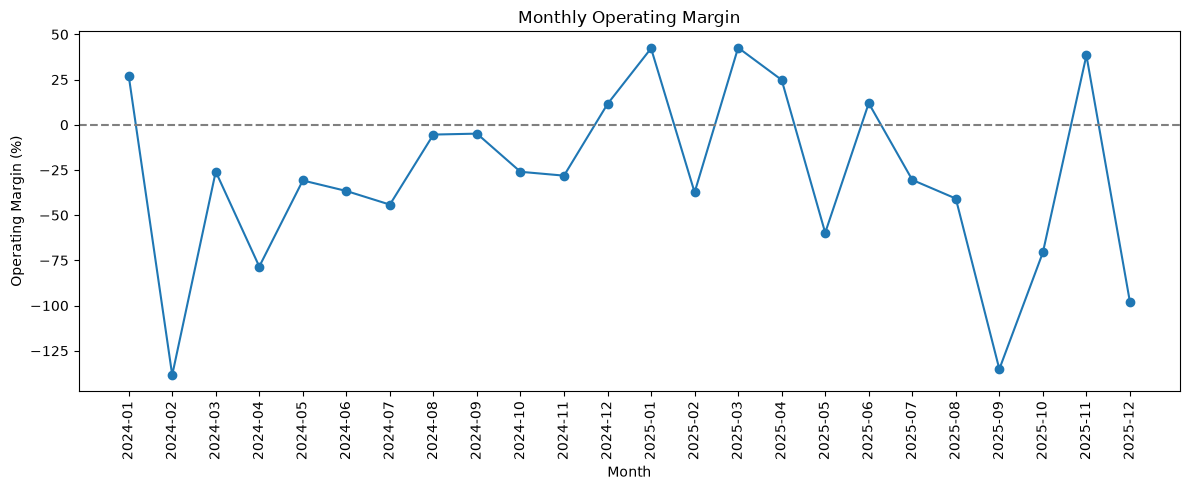

In [65]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_summary.index.astype(str),
    monthly_summary["operating_margin"] * 100,
    marker = 'o')

plt.axhline(0, color="gray", linestyle="--")
plt.xlabel("Month")
plt.ylabel("Operating Margin (%)")
plt.title("Monthly Operating Margin")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


In [53]:
dated_transaction['month']

0       2025-09
1       2024-02
2       2025-08
3       2024-07
4       2025-11
         ...   
2145    2024-02
2146    2024-03
2147    2024-03
2148    2024-07
2149    2025-10
Name: month, Length: 2113, dtype: period[M]

In [54]:
#checking feb 2024 expenses
dated_transaction.loc[(dated_transaction['record_type_clean'] == 'operating expense') & (dated_transaction['month'] == '2024-02') ,['transaction_id', 'date_clean', 'category','operating_expense_number']].sort_values(by='operating_expense_number', ascending=False)

,transaction_id,date_clean,category,operating_expense_number
163,TXN-001832,2024-02-14,Rent,3435.30
1089,TXN-001937,2024-02-15,Rent,3067.46
934,TXN-001852,2024-02-14,Rent,2330.47
2145,TXN-001839,2024-02-27,Insurance,477.72
995,TXN-001911,2024-02-03,Insurance,448.37
1518,TXN-001944,2024-02-04,Insurance,387.58
1858,TXN-001863,2024-02-17,Utilities,305.00


In [55]:
#checking feb 2024 rent
dated_transaction.loc[(dated_transaction['record_type_clean'] == 'operating expense') & (dated_transaction['month'] == '2024-02') & (dated_transaction['category'] == 'Rent'),['transaction_id', 'date_clean', 'category','operating_expense_number','vendor','notes', 'source_file']].sort_values(by='operating_expense_number', ascending=False)

,transaction_id,date_clean,category,operating_expense_number,vendor,notes,source_file
163,TXN-001832,2024-02-14,Rent,3435.30,City Center Properties,recurring monthly charge,expenses_Feb_2024.csv
1089,TXN-001937,2024-02-15,Rent,3067.46,City Center Properties,NaN,expenses_Feb_2024.csv
934,TXN-001852,2024-02-14,Rent,2330.47,City Center Properties,approved by owner,expenses_Feb_2024.csv


In [56]:
#verifying if any other month had multiple rent payments
dated_transaction.loc[(dated_transaction['record_type_clean'] == 'operating expense') & (dated_transaction['category'] == 'Rent'),'month'].value_counts().sort_index()

month
2024-02    3
2024-03    1
2024-04    1
2024-05    1
2024-06    1
2024-09    1
2024-10    1
2025-02    1
2025-05    1
2025-07    1
2025-08    1
2025-09    1
2025-10    2
2025-12    2
Freq: M, Name: count, dtype: int64

In [57]:
#verifying if rent is classified under any other record type
dated_transaction.loc[(dated_transaction['category'] == 'Rent'),['month','record_type_clean']].value_counts()

month    record_type_clean
2024-02  operating expense    3
2025-10  operating expense    2
2025-12  operating expense    2
2024-05  operating expense    1
2025-08  operating expense    1
2025-05  operating expense    1
2025-02  operating expense    1
2024-10  operating expense    1
2024-04  operating expense    1
2024-06  operating expense    1
2025-09  operating expense    1
2024-09  operating expense    1
2024-03  operating expense    1
2025-07  operating expense    1
Name: count, dtype: int64

In [58]:
#Checking sept 2025 expenses
dated_transaction.loc[(dated_transaction['record_type_clean'] == 'operating expense') & (dated_transaction['month'] == '2025-09')  ,['transaction_id', 'date_clean', 'category','operating_expense_number']].sort_values(by='operating_expense_number', ascending=False)

,transaction_id,date_clean,category,operating_expense_number
1761,TXN-001879,2025-09-03,Rent,2862.55
92,TXN-001958,2025-09-30,Payroll,1437.74
103,TXN-001906,2025-09-27,Payroll,1393.64
162,TXN-001919,2025-09-23,Payroll,1207.62
659,TXN-001831,2025-09-29,Payroll,1073.32
1646,TXN-001853,2025-09-15,Insurance,517.68
1585,TXN-001875,2025-09-26,Insurance,473.37
1218,TXN-001916,2025-09-19,Insurance,364.98
902,TXN-001834,2025-09-01,Delivery Fuel,249.24
769,TXN-001850,2025-09-08,Delivery Fuel,168.02


In [59]:
#Checking Dec 2025 expenses
dated_transaction.loc[(dated_transaction['record_type_clean'] == 'operating expense') & (dated_transaction['month'] == '2025-12')  ,['transaction_id', 'date_clean', 'category','operating_expense_number']].sort_values(by='operating_expense_number', ascending=False)

,transaction_id,date_clean,category,operating_expense_number
538,TXN-001956,2025-12-11,Rent,3418.49
1096,TXN-001876,2025-12-26,Rent,3265.56
423,TXN-001947,2025-12-24,Payroll,1183.18
854,TXN-001957,2025-12-18,Marketing,504.80
1730,TXN-001903,2025-12-22,Insurance,498.78
1192,TXN-001870,2025-12-27,Insurance,384.40
921,TXN-001898,2025-12-13,Delivery Fuel,211.97
391,TXN-001924,2025-12-04,Office Supplies,110.82


In [ ]:
#looking at highest expenses by month and category
dated_transaction[['month','category','operating_expense_number']].sort_values('operating_expense_number', ascending=False).head(25)

,month,category,operating_expense_number
326,2025-08,Rent,3471.56
1599,2024-06,Rent,3454.60
163,2024-02,Rent,3435.30
538,2025-12,Rent,3418.49
1096,2025-12,Rent,3265.56
97,2024-05,Rent,3255.72
1800,2024-09,Rent,3208.37
1822,2024-03,Rent,3134.21
607,2025-02,Rent,3089.31
1089,2024-02,Rent,3067.46


In [61]:
#restting the index and exporting monthly finacial data
monthly_export = monthly_summary.reset_index()

monthly_export.to_csv('monthly_financial_summary.csv', index=False)

In [ ]:
#exporting opex data
monthly_export_opex = dated_transaction.loc[dated_transaction['record_type_clean'] =='operating expense',['month','category','notes','operating_expense_number','date_clean']]

monthly_export_opex.to_csv('monthly_financial_summary_opex.csv',index=False)